# Laboratorio 6 — Análisis de redes sociales (YouTube)

In [1]:
import json
import re
import warnings
from collections import Counter
from itertools import islice

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

RANDOM_STATE = 42
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

## 1. Carga, comprensión e integración de los datos

In [2]:
videos = pd.read_csv("data/youtube_videos.csv", encoding="utf-8")
comments = pd.read_csv("data/youtube_comments.csv", encoding="utf-8")

print("youtube_videos.csv ->", videos.shape)
print("youtube_comments.csv ->", comments.shape)

youtube_videos.csv -> (293, 20)
youtube_comments.csv -> (406, 17)


### 1.1 Carga

Ambos archivos se cargan con `pandas.read_csv` usando codificación UTF-8, que es
la codificación en la que están guardados los archivos originales.

In [3]:
videos.head(3)

,video_id,title,channel_name,channel_id,source_query,source_group,dataset_sources,channel_handle,published_time,view_count_text,description_snippet,video_url,query_hits,keywords,description,view_count,publish_date,upload_date,category,owner_handle
0,-5puKGEqcUc,INSIVUMEH pronostica incremento de lluvias par...,T13 Noticias Guatemala,UCq0Cm-3SKthEySQc2JZBi1A,guatemala lluvias,topic,youtube_guatemala.csv | youtube_guatemala_lab....,/@T13NoticiasGuatemala,hace 2 días,"2,390 vistas",El Departamento de Pronóstico de INSIVUMEH pre...,https://www.youtube.com/watch?v=-5puKGEqcUc,"[""guatemala lluvias""]","[""Canícula prolongada"", ""Chapin tv"", ""Fenómeno...",El Departamento de Pronóstico de INSIVUMEH pre...,2357,2026-08-28T22:00:20-07:00,2026-08-28T22:00:20-07:00,News & Politics,/@T13NoticiasGuatemala
1,-E7OPOLjMug,BERNARDO ARÉVALO CALIFICA CAMBIO EN EL MP COMO...,IDocumenta,UCgItjn_ZWFWcv1MlpKIkqgQ,@GobiernodelaRepublicadeGuatema,topic,youtube_target_channels.csv,/@iDocumenta,hace 3 meses,4 vistas,"El presidente de Guatemala, Bernardo Arévalo, ...",https://www.youtube.com/watch?v=-E7OPOLjMug,"[""@GobiernodelaRepublicadeGuatema""]",[],"El presidente de Guatemala, Bernardo Arévalo, ...",4,2026-05-13T16:00:03-07:00,2026-05-13T16:00:03-07:00,People & Blogs,/@iDocumenta
2,-KDglrIzRKo,¡HISTÓRICO! Mexico recupera petróleo robado po...,México Poder,UC-DpoeBbCMOMOH1-j71KPqA,guatemala noticias,topic,youtube_guatemala.csv | youtube_guatemala_lab....,/@M%C3%A9xicoPoder,hace 1 día,"29,736 vistas",México #PetróleoMexicano #SoberaníaEnergética ...,https://www.youtube.com/watch?v=-KDglrIzRKo,"[""guatemala noticias""]","[""Mexico recupera petroleo"", ""petroleo robado ...",#México #PetróleoMexicano #SoberaníaEnergética...,29736,2026-08-29T17:00:38-07:00,2026-08-29T17:00:38-07:00,People & Blogs,/@M%C3%A9xicoPoder


In [4]:
comments.head(3)

,video_id,comment_id,video_title,channel_name,channel_id,author_name,author_channel_id,text,source_query,source_group,dataset_sources,author_handle,published_text,like_count_text,reply_count,is_pinned,viewer_rating
0,j43HgwYFKfk,Ugw-J65a1iYL9hqhELh4AaABAg,La cooptación de Walter Mazariegos en la USAC,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,@MarcosCarillo-b1r,UCdFlugHJJa4l3YqWuNRmvXw,Ese corrupto amigo de la vieja fiscal los teng...,@quorumgt,topic,j43HgwYFKfk_out_comments.csv | quorum_complete...,/@MarcosCarillo-b1r,hace 6 meses,,0,False,NaN
1,06mFNPU0aB8,Ugw-ZT9t9wU2V-tCaUZ4AaABAg,Capturan a presuntos delincuentes disfrazados ...,Noti7,UCVpSRoZgngfSL03Nlbjtq9A,@RaulPerez-cw2vi,UCvl1tzQeBeGy6efPTRJXSCw,"Están jóvenes porque no buscan un trabajo, tu...",guatemala noticias,topic,youtube_guatemala_comments.csv | youtube_guate...,/@RaulPerez-cw2vi,hace 2 semanas,,0,False,NaN
2,j43HgwYFKfk,Ugw0xaOb2CYXXoudtwJ4AaABAg,La cooptación de Walter Mazariegos en la USAC,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,@iamjimalesssa,UCRAquv8el-tQ30bN7MlmySQ,Me dejaron con ganas de demandar la ilegalidad...,@quorumgt,topic,j43HgwYFKfk_out_comments.csv | quorum_complete...,/@iamjimalesssa,hace 1 año,4,0,False,NaN


### 1.2 Unidad de observación, llave primaria y variables relevantes

**`youtube_videos.csv`**
- Unidad de observación: **un video de YouTube**.
- Llave primaria: `video_id` (única, sin duplicados — se verifica abajo).
- Variables relevantes: `channel_id` (identificador estable del canal),
  `title`/`description`/`keywords` (contenido para análisis de texto y temas),
  `view_count` (popularidad), `category` (tema editorial asignado por YouTube),
  `source_query`/`source_group` (procedimiento de muestreo, no el tema real del
  video), `publish_date` (fecha exacta de publicación).

**`youtube_comments.csv`**
- Unidad de observación: **un comentario principal publicado en un video**.
- Llave primaria: `comment_id` (única, sin duplicados — se verifica abajo).
- Llave foránea hacia `youtube_videos.csv`: `video_id`.
- Variables relevantes: `author_channel_id` (identificador estable del autor,
  se usará como nodo en la red), `text` (contenido para análisis de tópicos y
  sentimiento), `like_count_text` y `reply_count` (intensidad de reacción a un
  comentario).

In [5]:
print("video_id duplicados en videos:", videos["video_id"].duplicated().sum())
print("comment_id duplicados en comments:", comments["comment_id"].duplicated().sum())

video_id duplicados en videos: 0
comment_id duplicados en comments: 0


### 1.3 Relación entre canal, video, autor, comentario, categoría y consulta de búsqueda

```
channel (channel_id) ---publica---> video (video_id) ---categoria---> category
                                        |
                                        | recuperado mediante
                                        v
                              source_query / source_group
                                        |
                                        | recibe comentarios de
                                        v
                 author (author_channel_id) ---escribe---> comment (comment_id)
```

- Un **canal** (`channel_id`) publica cero o más **videos** (`video_id`); la
  relación canal→video es 1→N.
- Cada video tiene asignada una **categoría** editorial de YouTube (`category`)
  y fue recuperado mediante una o varias **consultas de búsqueda**
  (`source_query`, y de forma más granular `query_hits`); esto describe el
  *muestreo*, no necesariamente el tema real del contenido.
- Un **autor** (`author_channel_id`) es una cuenta de YouTube distinta del
  canal que publicó el video comentado; un autor puede escribir uno o varios
  **comentarios** (`comment_id`) y, potencialmente, comentar en más de un
  video. La relación autor→comentario es 1→N; la relación
  autor↔video (a través de los comentarios) es N↔M y es precisamente la que
  se modela como red bipartita en el ejercicio 4.
- **Importante:** el canal que sube el video y el autor que comenta son
  entidades distintas (`channel_id` vs. `author_channel_id`); no deben
  confundirse aunque ambas sean "cuentas de YouTube".

### 1.4 Integración mediante `video_id`

In [6]:
comments_videos = comments.merge(
    videos, on="video_id", how="left", suffixes=("_comment", "_video"), indicator=True
)

match_counts = comments_videos["_merge"].value_counts()
print(match_counts)

n_matched = (comments_videos["_merge"] == "both").sum()
print(f"\nComentarios que pudieron asociarse con un video: {n_matched} de {len(comments)} "
      f"({n_matched / len(comments):.1%})")

_merge
both          406
left_only       0
right_only      0
Name: count, dtype: int64

Comentarios que pudieron asociarse con un video: 406 de 406 (100.0%)


In [7]:
videos_con_comentarios = comments["video_id"].nunique()
print(f"Videos distintos que aparecen en youtube_comments.csv: {videos_con_comentarios}")
print(f"Videos totales en youtube_videos.csv: {videos.shape[0]}")
print(f"Proporción de videos con al menos un comentario en la muestra: "
      f"{videos_con_comentarios / videos.shape[0]:.1%}")

Videos distintos que aparecen en youtube_comments.csv: 19
Videos totales en youtube_videos.csv: 293
Proporción de videos con al menos un comentario en la muestra: 6.5%


**Hallazgo clave para el resto del laboratorio:** el 100 % de los comentarios
(406/406) se asocian correctamente con un `video_id` presente en
`youtube_videos.csv`. Sin embargo, esos 406 comentarios se concentran en
**solo 19 de los 293 videos** (≈6.5 %). Es decir, la recolección de
comentarios fue selectiva y no cubrió todos los videos muestreados. Esto es
una limitación estructural que condiciona directamente la red bipartita del
ejercicio 4: la mayoría de los videos del dataset de videos nunca podrán
aparecer como nodo en la red autor–video porque no tienen comentarios
asociados.

## 2. Calidad, limpieza y preprocesamiento

### 2.1 Diagnóstico inicial de calidad

In [8]:
def resumen_calidad(df, nombre):
    resumen = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "n_faltantes": df.isna().sum(),
        "pct_faltantes": (df.isna().mean() * 100).round(1),
        "n_unicos": df.nunique(),
        "es_constante": df.nunique(dropna=False) <= 1,
    })
    print(f"--- {nombre}: {df.shape[0]} filas x {df.shape[1]} columnas ---")
    return resumen

resumen_videos = resumen_calidad(videos, "youtube_videos.csv")
resumen_videos

--- youtube_videos.csv: 293 filas x 20 columnas ---


,dtype,n_faltantes,pct_faltantes,n_unicos,es_constante
video_id,str,0,0.0,293,False
title,str,0,0.0,274,False
channel_name,str,0,0.0,97,False
channel_id,str,0,0.0,97,False
source_query,str,0,0.0,21,False
source_group,str,0,0.0,3,False
dataset_sources,str,0,0.0,23,False
channel_handle,str,0,0.0,97,False
published_time,str,13,4.4,80,False
view_count_text,str,13,4.4,259,False


In [9]:
resumen_comments = resumen_calidad(comments, "youtube_comments.csv")
resumen_comments

--- youtube_comments.csv: 406 filas x 17 columnas ---


,dtype,n_faltantes,pct_faltantes,n_unicos,es_constante
video_id,str,0,0.0,19,False
comment_id,str,0,0.0,406,False
video_title,str,0,0.0,19,False
channel_name,str,0,0.0,8,False
channel_id,str,0,0.0,8,False
author_name,str,0,0.0,332,False
author_channel_id,str,0,0.0,332,False
text,str,0,0.0,404,False
source_query,str,0,0.0,6,False
source_group,str,0,0.0,2,False


**Dimensiones:** 293 videos x 20 variables, 406 comentarios x 17 variables
(consistente con la ficha técnica del laboratorio).

**Valores faltantes:** en `videos`, `description_snippet` (25), `description`
(26), `published_time`/`view_count_text` (13 cada una) presentan nulos; el
resto de columnas está completo. En `comments` no hay valores nulos
representados como `NaN` en ninguna columna **excepto** `viewer_rating`, que
está vacía en el 100 % de los 406 registros.

**Duplicados:** no existen filas completamente duplicadas ni duplicados de
`video_id` en `videos` ni de `comment_id` en `comments` (verificado en 1.2).
Sí existen registros con el mismo `author_channel_id` y `video_id` (un mismo
autor comentando varias veces el mismo video), lo cual es válido y se
convierte en el peso de la arista en la red bipartita.

**Variables constantes:** `is_pinned` toma el valor `False` en el 100 % de
los registros (0 varianza) y `viewer_rating` está vacía en el 100 % de los
registros.

In [10]:
print("is_pinned valores únicos:", comments["is_pinned"].unique())
print("viewer_rating no nulos:", comments["viewer_rating"].notna().sum(), "de", len(comments))

is_pinned valores únicos: [False]
viewer_rating no nulos: 0 de 406


**Valores atípicos (outliers):** `view_count` y `like_count` (una vez
convertida a numérica en 2.4) tienen distribuciones muy sesgadas a la derecha,
típicas de fenómenos de popularidad en redes sociales (unos pocos videos con
visualizaciones extremas). Se visualiza en escala logarítmica para no ocultar
la mayoría de las observaciones detrás de unos pocos valores extremos.

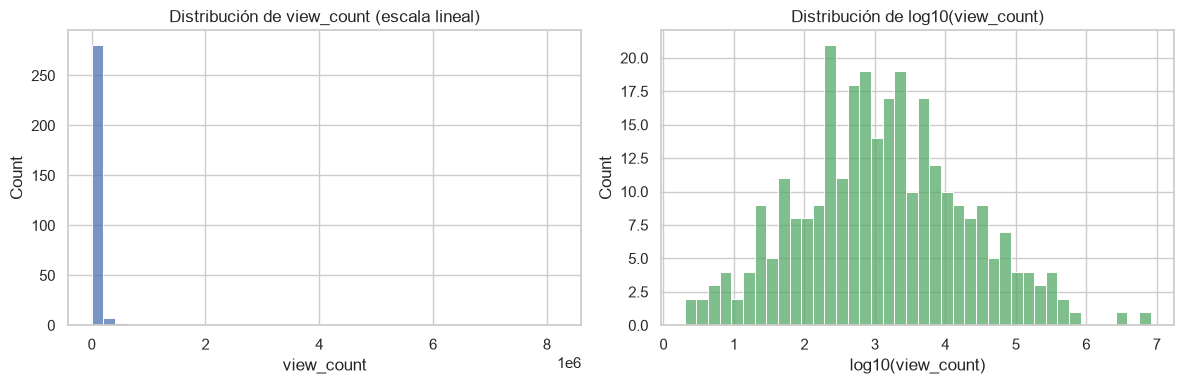

count    2.930000e+02
mean     6.043009e+04
std      5.157983e+05
min      2.000000e+00
25%      2.150000e+02
50%      1.175000e+03
75%      7.465000e+03
max      8.190449e+06
Name: view_count, dtype: float64


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(videos["view_count"], bins=40, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribución de view_count (escala lineal)")
sns.histplot(np.log10(videos["view_count"].clip(lower=1)), bins=40, ax=axes[1], color="#55A868")
axes[1].set_title("Distribución de log10(view_count)")
axes[1].set_xlabel("log10(view_count)")
plt.tight_layout()
plt.show()

print(videos["view_count"].describe())

**Consistencia entre identificadores, nombres y handles:**
- `channel_id` ↔ `channel_name`: 97 valores únicos de cada uno en `videos`, y
  ningún `channel_id` está asociado a más de un `channel_name` distinto en
  este corte de datos. Aun así, se conserva `channel_id` como identificador
  porque la documentación advierte que el nombre visible puede cambiar.
- `author_channel_id` ↔ `author_name` en `comments`: 332 valores únicos de
  cada uno, con correspondencia 1 a 1 en esta muestra.
- `channel_handle` y `owner_handle` son idénticos en el 100 % de las filas de
  `videos`; `upload_date` y `publish_date` también son idénticos en el 100 %
  de las filas. Ambos pares de columnas son redundantes entre sí.

In [12]:
chk = pd.DataFrame({
    "channel_id_unicos": [videos["channel_id"].nunique()],
    "channel_name_unicos": [videos["channel_name"].nunique()],
    "channel_id_con_mas_de_1_nombre": [(videos.groupby("channel_id")["channel_name"].nunique() > 1).sum()],
    "author_channel_id_unicos": [comments["author_channel_id"].nunique()],
    "author_name_unicos": [comments["author_name"].nunique()],
    "channel_handle_igual_owner_handle_pct": [(videos["channel_handle"] == videos["owner_handle"]).mean()],
    "upload_date_igual_publish_date_pct": [(videos["upload_date"] == videos["publish_date"]).mean()],
})
chk.T

,0
channel_id_unicos,97.0
channel_name_unicos,97.0
channel_id_con_mas_de_1_nombre,0.0
author_channel_id_unicos,332.0
author_name_unicos,332.0
channel_handle_igual_owner_handle_pct,1.0
upload_date_igual_publish_date_pct,1.0


### 2.2 Variables problemáticas o de uso delicado

| Variable | Problema | Tratamiento |
|---|---|---|
| `viewer_rating` | 100 % vacía | Se excluye del análisis; no aporta información. |
| `is_pinned` | Constante (`False`) | Se excluye de cualquier modelo o comparación; no discrimina. |
| `published_time` (videos) / `published_text` (comments) | Tiempo **relativo** a la fecha de recolección (p. ej. "hace 2 días"), no una fecha exacta. La fecha de recolección no está registrada de forma explícita para los comentarios. | No se convierte a fecha absoluta; se usa únicamente de forma cualitativa (orden aproximado) y se documenta como limitación temporal en la sección 10. |
| `description_snippet` | Fragmento truncado y redundante de `description`; tiene nulos que no implican ausencia real de descripción. | Se prioriza `description` completa; `description_snippet` no se usa como fuente de texto. |
| `upload_date` / `channel_handle` / `owner_handle` | Idénticas a `publish_date` / `owner_handle` / `channel_handle` respectivamente en el 100 % de los casos | Se conserva solo una de cada par para evitar redundancia; no se eliminan físicamente las columnas por trazabilidad, pero no se usan ambas en el mismo análisis. |
| `query_hits`, `keywords`, `dataset_sources` | Almacenadas como texto con estructura de lista (`["a", "b"]` o `"a \| b"`) | Se parsean explícitamente a listas de Python antes de usarlas (ver 2.3). |
| `like_count_text` | Texto que puede estar vacío | Se convierte a numérico documentando el tratamiento de vacíos (ver 2.4). |
| `reply_count` | **No debe interpretarse como arista entre usuarios** (ver advertencia del enunciado) | Se usa únicamente como atributo descriptivo del comentario, nunca para construir relaciones autor–autor. |

### 2.3 Normalización de identificadores y nombres

Se conservan `channel_id`, `video_id`, `comment_id` y `author_channel_id`
como identificadores en todas las tablas y en la red. Los nombres visibles
(`channel_name`, `author_name`, handles) se guardan únicamente como
**atributos descriptivos** en tablas de referencia (lookups), nunca como
llave de unión ni como identificador de nodo.

In [13]:
def parse_lista(valor):
    """Convierte una columna con estructura de lista en texto a una lista de Python."""
    if pd.isna(valor):
        return []
    valor = str(valor).strip()
    if valor.startswith("["):
        try:
            return json.loads(valor)
        except json.JSONDecodeError:
            return []
    return [v.strip() for v in valor.split("|") if v.strip()]

videos["keywords_lista"] = videos["keywords"].apply(parse_lista)
videos["query_hits_lista"] = videos["query_hits"].apply(parse_lista)
videos["dataset_sources_lista"] = videos["dataset_sources"].apply(parse_lista)
comments["dataset_sources_lista"] = comments["dataset_sources"].apply(parse_lista)

videos[["keywords", "keywords_lista"]].head(3)

,keywords,keywords_lista
0,"[""Canícula prolongada"", ""Chapin tv"", ""Fenómeno...","[Canícula prolongada, Chapin tv, Fenómeno del ..."
1,[],[]
2,"[""Mexico recupera petroleo"", ""petroleo robado ...","[Mexico recupera petroleo, petroleo robado Gua..."


In [14]:
# Tablas de referencia (lookup) nombre visible <- identificador estable
lookup_canales = (
    videos.groupby("channel_id")["channel_name"]
    .agg(lambda s: s.mode().iat[0])
    .rename("channel_name_normalizado")
)
lookup_autores = (
    comments.groupby("author_channel_id")["author_name"]
    .agg(lambda s: s.mode().iat[0])
    .rename("author_name_normalizado")
)

print(lookup_canales.head())
print(lookup_autores.head())

channel_id
UC-DpoeBbCMOMOH1-j71KPqA                             México Poder
UC-GLagjBhWAZ3IOWFgzqIAw                            Canal Antigua
UC-YGRGi0FeIA5441bGlHOPw                           audioschileros
UC-ZtFBHzgkYFh7whZkuR_Ag    Gobierno de la República de Guatemala
UC-rcR68a-aLwAnszxTG4--A                                 Panda 01
Name: channel_name_normalizado, dtype: str
author_channel_id
UC-HeUTT6_g-VoiWds2a4H-w                @JorgeMunoz-gd9et
UC-Iul5tDYH_oiAMXQH-KaaQ             @AlbertoMancilla-p9h
UC-QOpE7GOxlXcHZ8b7HbQKA               @mariaalexander427
UC-fiZBS5Gp1eCJd9ucgWnCg                       @Tommii.10
UC-hfX8J5JPJ-dfuakzegMLA    @normaleticiaorozcojuarez2418
Name: author_name_normalizado, dtype: str


### 2.4 Conversión de variables de conteo almacenadas como texto

`view_count` ya viene como entero (`int64`) en el archivo original y es la
variable recomendada por la ficha técnica para cálculos de popularidad, por
lo que **no se recalcula desde `view_count_text`**; únicamente se valida que
ambas sean consistentes entre sí para detectar posibles errores de scraping.

`like_count_text` sí debe convertirse: es texto que puede venir vacío. Se
inspeccionó la columna completa y **no contiene** separadores de miles,
abreviaturas (`K`/`M`/`mil`) ni valores no numéricos distintos de la cadena
vacía; por lo tanto el tratamiento es: `strip()` de espacios → cadena vacía
se marca como valor faltante (`NaN`) → conversión a entero nullable
(`Int64`).

In [15]:
def parsear_conteo_texto(serie, quitar_sufijo=None):
    s = serie.astype(str).str.strip()
    if quitar_sufijo:
        s = s.str.replace(quitar_sufijo, "", regex=False).str.strip()
    s = s.str.replace(",", "", regex=False)
    s = s.replace({"": np.nan, "nan": np.nan})
    return pd.to_numeric(s, errors="coerce").astype("Int64")

comments["like_count"] = parsear_conteo_texto(comments["like_count_text"])
videos["view_count_parseado"] = parsear_conteo_texto(videos["view_count_text"], quitar_sufijo=" vistas")

print("like_count -> faltantes:", comments["like_count"].isna().sum(), "de", len(comments))
print("¿view_count_parseado coincide con view_count?",
      (videos["view_count_parseado"] == videos["view_count"]).mean())

like_count -> faltantes: 189 de 406
¿view_count_parseado coincide con view_count? 0.8107142857142857


El campo `like_count_text` viene vacío (no `"0"`) en 189 de 406 comentarios
(≈46.5 %). YouTube normalmente sí muestra "0" cuando un comentario no tiene
"me gusta", así que un vacío es más probablemente un valor **no capturado por
el scraper** que una ausencia real de "me gusta". Ante esta ambigüedad, se
documenta explícitamente y se opta por **no imputar con 0 de forma
silenciosa**: se conserva `like_count` con `NaN` para no sesgar los
estadísticos, y se reporta el porcentaje de faltantes cada vez que se use la
variable.

### 2.5 y 2.6 Texto original y texto limpio

Se crean dos columnas sobre `comments["text"]`:
- **`texto_original`**: copia exacta del texto tal como fue publicado. Se
  conserva sin modificar para auditoría y para el análisis de sentimiento
  del ejercicio 9 (los léxicos y modelos de sentimiento en español se
  entrenan sobre texto natural, incluyendo mayúsculas, signos de puntuación
  y emojis, que son señales relevantes de tono).
- **`texto_limpio`**: versión normalizada para análisis de frecuencias,
  tópicos y construcción de vocabulario.

Decisiones documentadas para `texto_limpio`:

| Paso | Decisión | Justificación |
|---|---|---|
| Minúsculas | Sí | Evita tratar "Guatemala" y "guatemala" como palabras distintas. |
| URLs | Se eliminan | No aportan contenido textual analizable. |
| Hashtags | Se extraen a la columna `hashtags` y se conserva la palabra sin el símbolo `#` en el texto limpio | El símbolo no aporta valor semántico pero la palabra sí puede ser relevante para frecuencias. |
| Menciones (`@usuario`) | Se extraen a la columna `mentions` y se eliminan del texto limpio | Son identificadores de otras cuentas, no palabras de contenido; conservarlas infla artificialmente el vocabulario con nombres de usuario. |
| Emojis | Se convierten a texto descriptivo en español (p. ej. 😂 → "cara revolcandose de la risa") en vez de eliminarse | Los emojis cargan información afectiva relevante para el análisis de sentimiento y de tópicos; eliminarlos perdería esa señal. |
| Puntuación | Se elimina | No aporta a conteo de palabras/bigramas. |
| Números | Se eliminan como tokens sueltos | Los números sueltos (fechas relativas, conteos) no son informativos para tópicos; se documenta que esto podría eliminar años o cifras relevantes en pocos casos. |
| Stopwords en español | Se eliminan (lista de NLTK para español) | Reduce ruido en frecuencias y nubes de palabras. |
| Lematización | Se aplica con `simplemma` (diccionario de lemas en español) | Agrupa variantes flexivas de una misma palabra (p. ej. "corruptos"/"corrupto") bajo un mismo lema, mejorando el conteo de frecuencias. Se prefiere sobre spaCy por ser una librería pura de Python, sin dependencias compiladas ni descarga de modelos grandes, lo que la hace más reproducible entre sistemas operativos. |

In [16]:
import nltk

for recurso in ["stopwords"]:
    try:
        nltk.data.find(f"corpora/{recurso}")
    except LookupError:
        nltk.download(recurso, quiet=True)

from nltk.corpus import stopwords as nltk_stopwords

STOPWORDS_ES = set(nltk_stopwords.words("spanish"))
print(f"{len(STOPWORDS_ES)} stopwords en español cargadas (NLTK).")

313 stopwords en español cargadas (NLTK).


In [17]:
import simplemma

def lematizar_token(token):
    return simplemma.lemmatize(token, lang="es")

print("Lematizador (simplemma, es) listo:", lematizar_token("corruptos"), "<-", "corruptos")

Lematizador (simplemma, es) listo: corrupto <- corruptos


In [18]:
import emoji as emoji_lib

URL_RE = re.compile(r"https?://\S+|www\.\S+")
HASHTAG_RE = re.compile(r"#(\w+)")
MENTION_RE = re.compile(r"@(\w+)")
PUNCT_RE = re.compile(r"[^\wñáéíóúü\s]", flags=re.IGNORECASE)
NUMERO_RE = re.compile(r"\b\d+\b")
ESPACIOS_RE = re.compile(r"\s+")


def extraer_hashtags(texto):
    return HASHTAG_RE.findall(str(texto))


def extraer_menciones(texto):
    return MENTION_RE.findall(str(texto))


def limpiar_texto_basico(texto):
    """Minúsculas, URLs, emojis, hashtags/menciones, puntuación y números."""
    t = str(texto).lower()
    t = URL_RE.sub(" ", t)
    t = emoji_lib.demojize(t, language="es")
    t = t.replace(":", " ").replace("_", " ")
    t = MENTION_RE.sub(" ", t)
    t = HASHTAG_RE.sub(lambda m: " " + m.group(1) + " ", t)
    t = PUNCT_RE.sub(" ", t)
    t = NUMERO_RE.sub(" ", t)
    t = ESPACIOS_RE.sub(" ", t).strip()
    return t


def quitar_stopwords_y_lematizar(texto_basico):
    if not texto_basico:
        return ""
    lemas = []
    for token in texto_basico.split():
        if len(token) <= 1 or token in STOPWORDS_ES:
            continue
        lema = lematizar_token(token)
        if lema in STOPWORDS_ES:
            continue
        lemas.append(lema)
    return " ".join(lemas)


def limpiar_texto(texto):
    return quitar_stopwords_y_lematizar(limpiar_texto_basico(texto))

In [19]:
comments["texto_original"] = comments["text"]
comments["hashtags"] = comments["texto_original"].apply(extraer_hashtags)
comments["mentions"] = comments["texto_original"].apply(extraer_menciones)
comments["texto_limpio"] = comments["texto_original"].apply(limpiar_texto)

comments[["texto_original", "texto_limpio", "hashtags", "mentions"]].head(8)

,texto_original,texto_limpio,hashtags,mentions
0,Ese corrupto amigo de la vieja fiscal los teng...,corrupto amigo viejo fiscal verbo carcel,[],[]
1,"Están jóvenes porque no buscan un trabajo, tu...",joven buscar trabajo suerte policía gustar van...,[],[]
2,Me dejaron con ganas de demandar la ilegalidad...,dejar gana demandar ilegalidad reunión virtual...,[],[]
3,Veremos a este mafioso de Mazariegos en la cár...,ver mafioso mazariego cárcel buen tiempo sombra,[],[]
4,eso es para que salga de USA por su propio pie...,salir usar propio pie auto deportar,[],[]
5,Imagine if they had to walk back home.,imaginar if they had to walk back home,[],[]
6,buenísima investigacion :hand-purple-blue-peac...,bueno investigacion hand purple blue peace han...,[],[]
7,"Lleven su lonchera, sacrifiquense un poco. Y r...",llevar lonchera sacrificar reintevren dinero r...,[],[]


### 2.7 Efecto cuantificado de la limpieza

In [20]:
n_total = len(comments)
n_vacio_original = (comments["texto_original"].str.strip() == "").sum()
n_vacio_limpio = (comments["texto_limpio"].str.strip() == "").sum()

dup_original = comments["texto_original"].str.lower().str.strip().duplicated().sum()
dup_limpio = comments["texto_limpio"].duplicated().sum()

largo_antes = comments["texto_original"].str.len()
largo_despues = comments["texto_limpio"].str.len()

resumen_limpieza = pd.DataFrame({
    "métrica": [
        "Comentarios totales",
        "Textos vacíos (original)",
        "Textos vacíos (limpio)",
        "Duplicados de texto (original, case-insensitive)",
        "Duplicados de texto (limpio)",
        "Longitud media de texto (original, caracteres)",
        "Longitud media de texto (limpio, caracteres)",
        "Reducción media de longitud",
    ],
    "valor": [
        n_total,
        n_vacio_original,
        n_vacio_limpio,
        dup_original,
        dup_limpio,
        round(largo_antes.mean(), 1),
        round(largo_despues.mean(), 1),
        f"{(1 - largo_despues.mean() / largo_antes.mean()):.1%}",
    ],
})
resumen_limpieza

,métrica,valor
0,Comentarios totales,406
1,Textos vacíos (original),0
2,Textos vacíos (limpio),1
3,"Duplicados de texto (original, case-insensitive)",3
4,Duplicados de texto (limpio),4
5,"Longitud media de texto (original, caracteres)",139.2
6,"Longitud media de texto (limpio, caracteres)",94.7
7,Reducción media de longitud,32.0%


La limpieza no elimina registros (se conservan los 406 comentarios), pero sí
reduce drásticamente la longitud del texto (stopwords, puntuación y números
retirados) y puede producir `texto_limpio` vacío en comentarios que consistían
solo en stopwords, menciones, emojis o puntuación — estos casos se identifican
arriba y se excluyen únicamente de los análisis de frecuencia de palabras, no
del análisis de sentimiento (que usa `texto_original`).

In [21]:
comments.loc[comments["texto_limpio"].str.strip() == "", ["texto_original", "texto_limpio"]]

,texto_original,texto_limpio
97,que?,
